In [1]:
import pandas as pd #데이터 처리, 분석 라이브러리
import matplotlib.pyplot as plt #데이터 시각화 라이브러리
import seaborn as sns #통계 기반 시각화 라이브러리

In [2]:
from google.colab import drive #구글드라이브와 연결
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/titanic - titanic.csv') #구글 드라이브 내 타이타닉 데이터 불러오기
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


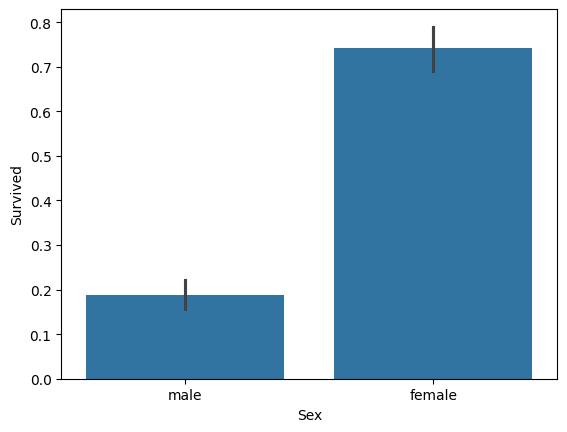

In [4]:
df['Age'] = df['Age'].fillna(df['Age'].mean()) #나이 결측치를 평균값으로 대체

sns.barplot(x='Sex', y='Survived', data=df) #성별에 따른 평균 생존률 막대그래프
plt.show()

In [5]:
survivors = df[df['Survived'] == 1] #생존자만 필터링해 별도의 데이터셋으로 추출

In [6]:
pclass_survivors = survivors.groupby('Pclass')['Survived'].count().reset_index() #객실 등급 별로 생존자 수 집계

print("--- 등급별 생존자 명수 결과 ---")
print(pclass_survivors)

--- 등급별 생존자 명수 결과 ---
   Pclass  Survived
0       1       136
1       2        87
2       3       119


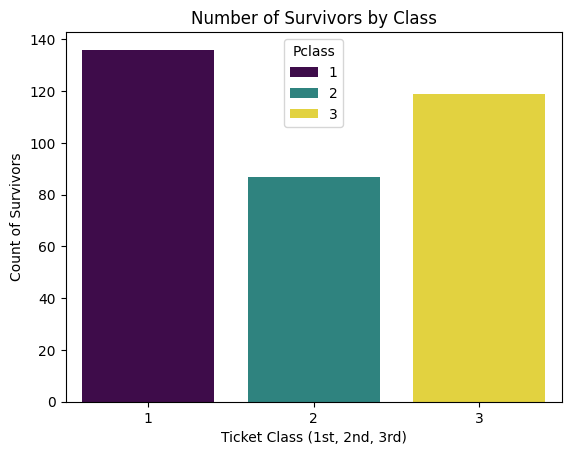

In [9]:
sns.barplot(x='Pclass', y='Survived', data=pclass_survivors, hue='Pclass', palette='viridis')
#객실 등급별 생존자 수를 막대그래프로 그리기

plt.title('Number of Survivors by Class') #제목
plt.xlabel('Ticket Class (1st, 2nd, 3rd)') #x축 : 등급
plt.ylabel('Count of Survivors') #y축 : 생존자 수
plt.show()

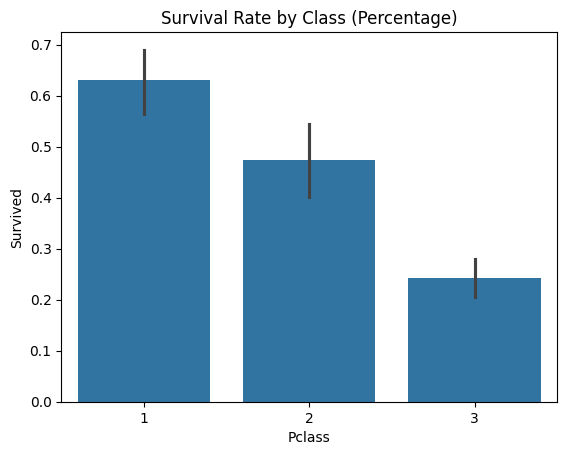

In [8]:
sns.barplot(x='Pclass', y='Survived', data=df) #객실 등급별 생존률을 그리기
plt.title('Survival Rate by Class (Percentage)')
plt.show()